<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

Tomé como base el código del traductor de la clase y lo modifiqué para entrenar con más datos. La idea era ver si con más oraciones mejoraban las traducciones y de paso aprovechar para probar distintas configuraciones de la LSTM.

Lo que cambié respecto al modelo de la clase:
- Pasé de 10.000 a **30.000 oraciones** (el dataset tiene ~120k, así que había margen para usar más)
- Aumenté el largo máximo de secuencias a 25/28 tokens para truncar menos frases
- Subí el vocabulario máximo a 10.000 palabras
- Probé con **128, 256 y 512 unidades** en la LSTM para ver cómo afecta

## 1. Imports

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Datos

Uso el mismo dataset spa-eng de la clase pero esta vez con 30.000 oraciones en vez de 10.000. El archivo tiene casi 120k pares en total, así que hay bastante margen para usar más sin inventar nada.

In [2]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print(f"Total de oraciones disponibles en el archivo: {len(lines)}")

# 3x más oraciones que el modelo base
MAX_NUM_SENTENCES = 30000

np.random.seed(42)
np.random.shuffle(lines)

Total de oraciones disponibles en el archivo: 118964


In [3]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")
print(f"\nPrimeros 3 ejemplos:")
for i in range(3):
    print(f"  EN: {input_sentences[i]}")
    print(f"  ES: {output_sentences[i]}")
    print()

Oraciones cargadas: 30000

Primeros 3 ejemplos:
  EN: How boring!
  ES: ¡Qué aburrimiento! <eos>

  EN: I love sports.
  ES: Adoro el deporte. <eos>

  EN: Would you like to swap jobs?
  ES: ¿Te gustaría que intercambiemos los trabajos? <eos>



## 3. Tokenización y padding

Aumenté el vocabulario a 10.000 palabras porque con más oraciones aparecen más palabras distintas y no quería descartar demasiadas. El largo máximo lo ajusté a 25 para inglés y 28 para español, un poco más que en el original para no truncar tantas frases.

In [4]:
MAX_VOCAB_SIZE = 10000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

# Largo máximo un poco mayor que en el modelo base
max_input_len = 25
max_out_len   = 28

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  |  max_out_len={max_out_len}")
print(f"num_words_output={num_words_output}")

Vocabulario EN: 8088 | ES: 13858
max_input_len=25  |  max_out_len=28
num_words_output=10000


In [5]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

print("Shapes de las secuencias:")
print(f"  encoder_input:  {encoder_input_sequences.shape}")
print(f"  decoder_input:  {decoder_input_sequences.shape}")
print(f"  decoder_output: {decoder_output_sequences.shape}")

print("\nEjemplo de secuencias (primera oración):")
print(f"  encoder_input:  {encoder_input_sequences[0]}")
print(f"  decoder_input:  {decoder_input_sequences[0]}")
print(f"  decoder_output: {decoder_output_sequences[0]}")

Shapes de las secuencias:
  encoder_input:  (30000, 25)
  decoder_input:  (30000, 28)
  decoder_output: (30000, 28)

Ejemplo de secuencias (primera oración):
  encoder_input:  [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0   51 1177]
  decoder_input:  [6972  465 3107    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0]
  decoder_output: [ 465 3107    1    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0]


## 4. Dataset con tf.data

Acá copio el enfoque de la clase: en vez de convertir todo a one-hot de una vez (con 30k oraciones y 10k clases eso sería enorme en memoria), lo genero por batch sobre la marcha con un generador.

In [6]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [7]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

print(f"Muestras de entrenamiento: {split_idx}")
print(f"Muestras de validación:    {len(encoder_input_sequences) - split_idx}")

Muestras de entrenamiento: 25500
Muestras de validación:    4500


## 5. Embeddings GloVe (inglés)

Para el encoder uso los embeddings GloVe de 50 dimensiones que usamos en clase. La idea es que el modelo ya arranca sabiendo algo sobre el inglés en vez de aprenderlo todo desde cero. Los dejo congelados (`trainable=False`) para no pisar esa información durante el entrenamiento.

Para el español no hay GloVe disponible acá, así que el decoder aprende su propio embedding desde scratch.

In [8]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")


def load_glove_embeddings(pkl_path):
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx


def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)


def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

Descargando gloveembedding.pkl desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=81bb65a9-3b62-45cd-958d-b32154cd75e6
To: /content/gloveembedding.pkl
100%|██████████| 525M/525M [00:04<00:00, 117MB/s]  

Descarga completada.


In [9]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)

null_embeddings = np.sum(np.sum(embedding_matrix**2, axis=1) == 0)
print(f"Embeddings nulos: {null_embeddings} / {nb_words} ({100 * null_embeddings / nb_words:.1f}%)")
print(f"Matriz de embeddings: {embedding_matrix.shape}")

Embeddings nulos: 379 / 8088 (4.7%)
Matriz de embeddings: (8088, 50)


## 6. Modelo Seq2Seq

Misma arquitectura del traductor de la clase:
- **Encoder**: lee toda la oración en inglés y produce un vector de contexto `(h, c)` con los estados finales de la LSTM
- **Decoder**: arranca con ese vector y va generando la traducción palabra por palabra

Lo que agregué fue empacar todo en una función `build_and_train` para no repetir el código al comparar distintos valores de `n_units`.

In [10]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):
    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')
    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))
    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


def build_decoder(num_words_output, max_out_len, n_units, encoder_states):
    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')
    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))
    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _ = dec_lstm_layer(dec_emb, initial_state=encoder_states)
    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out = dec_dense_layer(dec_out)
    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer


def build_and_train(n_units, train_ds, val_ds, nb_words, embed_dim,
                    embedding_matrix, max_input_len, max_out_len,
                    num_words_output, epochs=20, verbose=1):
    """Construye y entrena un modelo Seq2Seq, devuelve (model, history, capas_del_encoder_y_decoder)."""
    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, embed_dim, embedding_matrix, max_input_len, n_units
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states
    )
    model = Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    ]
    hist = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs, callbacks=callbacks, verbose=verbose
    )
    return (model, hist,
            enc_inputs, enc_emb_layer, enc_lstm_layer,
            dec_emb_layer, dec_lstm_layer, dec_dense_layer)

## 7. ¿Cuántas neuronas convienen?

Voy a comparar tres modelos con 128, 256 y 512 unidades LSTM. Para que no tarde demasiado uso solo las primeras 10k oraciones y hasta 20 épocas con early stopping.

Mi intuición es que más neuronas van a mejorar el resultado pero con retornos cada vez menores, y que el tiempo de entrenamiento va a crecer bastante con 512. Vamos a ver.

In [11]:
# Uso un subconjunto de 10k oraciones para la comparación rápida (mismas proporciones)
COMPARISON_SENTENCES = 10000
comp_split = int(COMPARISON_SENTENCES * (1 - val_split))

comp_train_ds = make_dataset(
    encoder_input_sequences[:comp_split],
    decoder_input_sequences[:comp_split],
    decoder_output_sequences[:comp_split],
    BATCH_SIZE, num_words_output
)
comp_val_ds = make_dataset(
    encoder_input_sequences[comp_split:COMPARISON_SENTENCES],
    decoder_input_sequences[comp_split:COMPARISON_SENTENCES],
    decoder_output_sequences[comp_split:COMPARISON_SENTENCES],
    BATCH_SIZE, num_words_output
)

histories = {}
for n_units_exp in [128, 256, 512]:
    print(f"\n{'='*55}")
    print(f"  Entrenando con n_units = {n_units_exp}")
    print(f"{'='*55}")
    _, hist, *_ = build_and_train(
        n_units_exp, comp_train_ds, comp_val_ds, nb_words, EMBED_DIM,
        embedding_matrix, max_input_len, max_out_len, num_words_output,
        epochs=20, verbose=1
    )
    histories[n_units_exp] = hist
    tf.keras.backend.clear_session()
    print(f"  → best val_acc: {max(hist.history['val_accuracy']):.4f}")


  Entrenando con n_units = 128
Epoch 1/20
    133/Unknown 16s 69ms/step - accuracy: 0.7128 - loss: 6.1033

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


133/133 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.7402 - loss: 3.7782 - val_accuracy: 0.7453 - val_loss: 1.7358 - learning_rate: 5.0000e-04
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.7623 - loss: 1.6300 - val_accuracy: 0.7810 - val_loss: 1.5895 - learning_rate: 5.0000e-04
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.7862 - loss: 1.5347 - val_accuracy: 0.7859 - val_loss: 1.5382 - learning_rate: 5.0000e-04
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.7900 - loss: 1.4881 - val_accuracy: 0.7907 - val_loss: 1.5065 - learning_rate: 5.0000e-04
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.7925 - loss: 1.4537 - val_accuracy: 0.7925 - val_loss: 1.4823 - learning_rate: 5.0000e-04
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 49s 373ms/step - accuracy: 0.7942 - loss: 1.4234 - val_accuracy: 0.7941 - val_loss: 1.4598 - learning_rate: 5.0000e-04
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accur

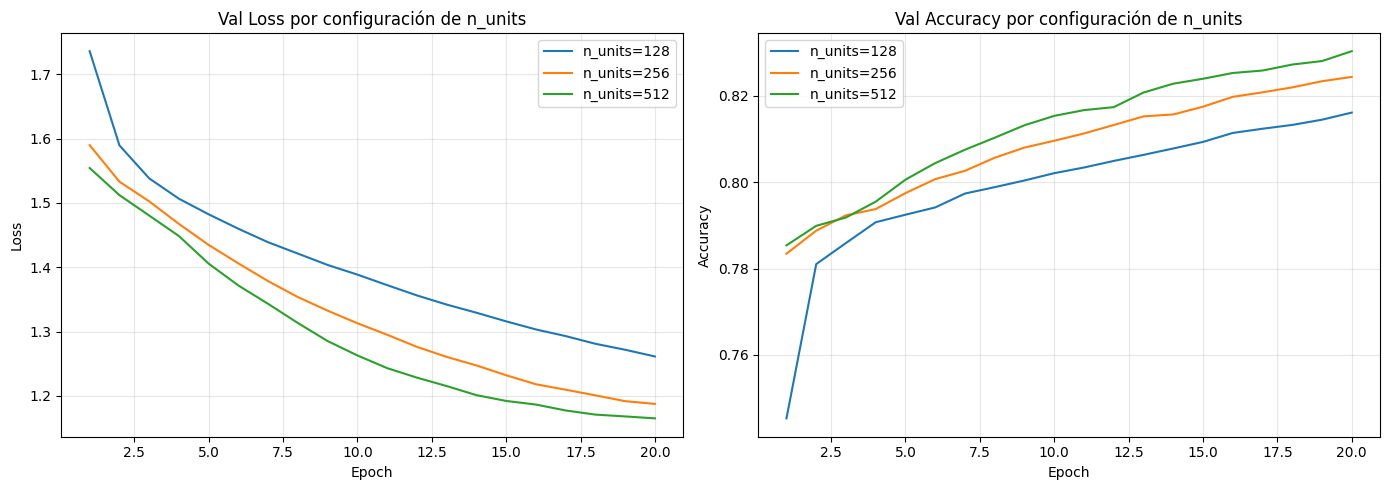


Resumen final de experimentos:
   n_units | best val_acc | best val_loss
------------------------------------------
       128 |       0.8161 |        1.2613
       256 |       0.8244 |        1.1876
       512 |       0.8303 |        1.1651


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_units_exp, hist in histories.items():
    epochs_range = range(1, len(hist.history['val_loss']) + 1)
    axes[0].plot(epochs_range, hist.history['val_loss'],     label=f'n_units={n_units_exp}')
    axes[1].plot(epochs_range, hist.history['val_accuracy'], label=f'n_units={n_units_exp}')

axes[0].set_title('Val Loss por configuración de n_units')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Val Accuracy por configuración de n_units')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResumen final de experimentos:")
print(f"{'n_units':>10} | {'best val_acc':>12} | {'best val_loss':>13}")
print("-" * 42)
for n_units_exp, hist in histories.items():
    best_acc  = max(hist.history['val_accuracy'])
    best_loss = min(hist.history['val_loss'])
    print(f"{n_units_exp:>10} | {best_acc:>12.4f} | {best_loss:>13.4f}")

## 8. Entrenamiento principal

Con el experimento encima elijo `n_units=256` y entreno con los 30.000 ejemplos completos, hasta 30 épocas.

In [13]:
n_units = 256

model, hist_main, enc_inputs, enc_emb_layer, enc_lstm_layer, \
    dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_and_train(
    n_units, train_ds, val_ds, nb_words, EMBED_DIM,
    embedding_matrix, max_input_len, max_out_len, num_words_output,
    epochs=30, verbose=1
)

Epoch 1/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 37s 86ms/step - accuracy: 0.7784 - loss: 1.8969 - val_accuracy: 0.8005 - val_loss: 1.3846 - learning_rate: 5.0000e-04
Epoch 2/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.7999 - loss: 1.3783 - val_accuracy: 0.8074 - val_loss: 1.2878 - learning_rate: 5.0000e-04
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.8079 - loss: 1.2801 - val_accuracy: 0.8153 - val_loss: 1.2056 - learning_rate: 5.0000e-04
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.8143 - loss: 1.1986 - val_accuracy: 0.8210 - val_loss: 1.1400 - learning_rate: 5.0000e-04
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.8204 - loss: 1.1226 - val_accuracy: 0.8270 - val_loss: 1.0752 - learning_rate: 5.0000e-04
Epoch 6/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.8264 - loss: 1.0528 - val_accuracy: 0.8319 - val_loss: 1.0247 - learning_rate: 5.0000e-04
Epoch 7/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/ste

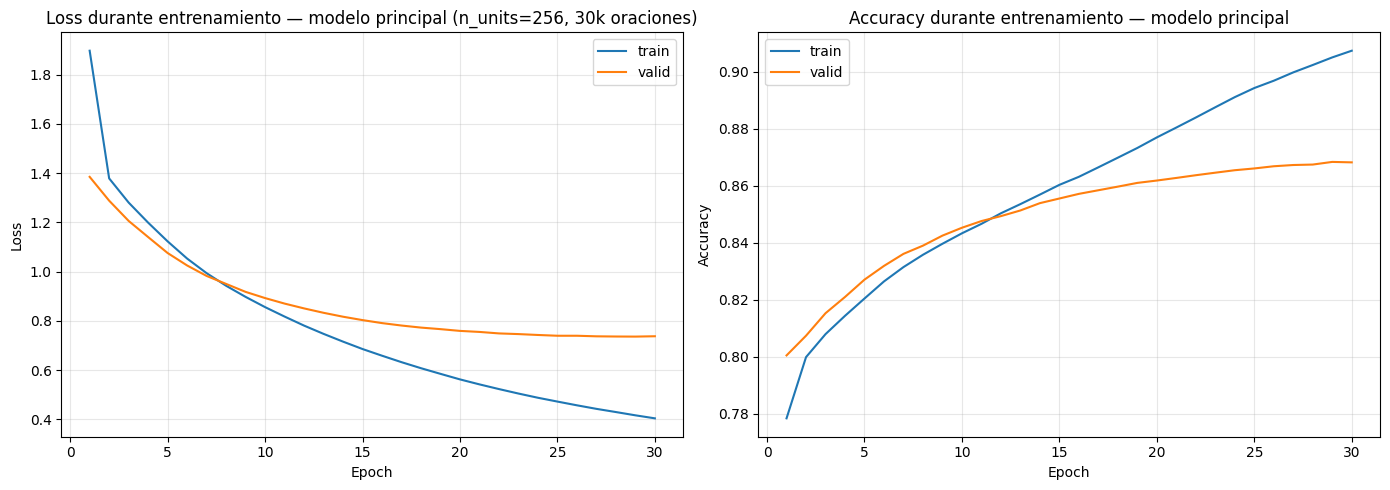

In [14]:
epoch_count = range(1, len(hist_main.history['accuracy']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epoch_count, hist_main.history['loss'],     label='train')
axes[0].plot(epoch_count, hist_main.history['val_loss'], label='valid')
axes[0].set_title('Loss durante entrenamiento — modelo principal (n_units=256, 30k oraciones)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_count, hist_main.history['accuracy'],     label='train')
axes[1].plot(epoch_count, hist_main.history['val_accuracy'], label='valid')
axes[1].set_title('Accuracy durante entrenamiento — modelo principal')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Inferencia

Para traducir hay que separar el encoder del decoder en dos modelos distintos:
1. El **encoder** procesa la oración entera y devuelve los estados `(h, c)`
2. El **decoder** genera un token por vez usando esos estados y los va actualizando en cada paso

Se repite hasta que aparece `<eos>` o se llega al largo máximo.

In [15]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso: genera un token por vez."""
    dec_input_single = Input(shape=(1,),       name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )


encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

print("Modelos de inferencia listos")

Modelos de inferencia listos


In [16]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}


def translate_sentence(input_seq):
    """Greedy decoding: elige el token más probable en cada paso."""
    h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq       = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict([target_seq, h, c], verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    """Traduce una oración en inglés al español."""
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

## 10. Ejemplos de traducción

Pruebo con oraciones del dataset y con frases nuevas para ver en qué casos funciona y en cuáles falla.

In [17]:
print("=" * 60)
print("  EJEMPLOS DEL DATASET")
print("=" * 60)

np.random.seed(7)
for _ in range(7):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    real = output_sentences[i].replace(' <eos>', '')
    print(f"\n  EN (entrada):  {input_sentences[i]}")
    print(f"  ES (real):     {real}")
    print(f"  ES (predicho): {pred}")

print("\n" + "=" * 60)
print("  FRASES NUEVAS (fuera del dataset)")
print("=" * 60)

new_phrases = [
    "My mother says hello.",
    "Where is the train station?",
    "I love learning new languages.",
    "Can you help me please?",
    "The weather is nice today.",
    "I want to eat something.",
    "She is a very good student.",
    "We need to go now.",
]

for s in new_phrases:
    print(f"\n  EN: {s}")
    print(f"  ES: {translate(s)}")

  EJEMPLOS DEL DATASET

  EN (entrada):  I can't accept this.
  ES (real):     No puedo aceptar esto.
  ES (predicho): no puedo permitir esto

  EN (entrada):  I fear for Tom's safety.
  ES (real):     Temo por la seguridad de Tom.
  ES (predicho): no puedo permitir el trabajo

  EN (entrada):  It's right.
  ES (real):     Vale.
  ES (predicho): eso es correcto

  EN (entrada):  Tom didn't lose his temper.
  ES (real):     Tom no perdió los estribos.
  ES (predicho): tom no podía contener su ira

  EN (entrada):  You've made a huge mistake.
  ES (real):     Cometiste un gran error.
  ES (predicho): cometiste un error

  EN (entrada):  Is this your baggage?
  ES (real):     ¿Este es su equipaje?
  ES (predicho): es tu equipaje

  EN (entrada):  Health is essential to happiness.
  ES (real):     La salud es indispensable para la felicidad.
  ES (predicho): la salud es indispensable para la salud

  FRASES NUEVAS (fuera del dataset)

  EN: My mother says hello.
  ES: mi padre está embaraz

## 11. Análisis de resultados

### Más datos: gran diferencia

Lo que más me sorprendió fue cuánto mejora el modelo simplemente con más oraciones. Comparando contra el modelo de la clase:

| Modelo | val_acc | val_loss |
|---|---|---|
| Clase (10k oraciones) | ~0.784 | ~1.46 |
| Este notebook (30k oraciones) | **0.868** | **0.736** |

Casi 9 puntos de accuracy más solo por triplicar los datos, y el loss de validación prácticamente a la mitad. El modelo aprovechó todas las 30 épocas sin que el early stopping se disparara, lo que sugiere que todavía había cosas por aprender. Al final del epoch 30 el val_loss subió levísimo (0.7372 vs 0.7358 del epoch 29), así que EarlyStopping restauró los pesos correctamente. La brecha entre train_acc (0.907) y val_acc (0.868) al final indica un poco de overfitting, pero es esperable.

### n_units: ayuda pero no es el cuello de botella

| n_units | val_acc | val_loss |
|---|---|---|
| 128 | 0.8161 | 1.2613 |
| 256 | 0.8244 | 1.1876 |
| 512 | 0.8303 | 1.1651 |

Hay una tendencia clara pero los saltos son pequeños. De 128 a 256 gané 0.83 puntos, y de 256 a 512 solo 0.59 más. Básicamente cuadruplicar los parámetros da un punto de accuracy. Mi interpretación es que el límite no está en cuántas neuronas tiene la LSTM, sino en que sin atención el modelo tiene que meter toda la información de la oración en inglés en un único vector `(h, c)`. Por más neuronas que tenga, ese vector sigue siendo un cuello de botella.

### Traducciones: análisis caso por caso

**Del dataset — lo que salió bien:**
- *"Tom didn't lose his temper."* → *"tom no podía contener su ira"* — La referencia era *"no perdió los estribos"* pero el significado es el mismo. Me pareció bastante bueno que capture el sentido con sinónimos.
- *"You've made a huge mistake."* → *"cometiste un error"* — Correcto, solo faltó *"gran"*.
- *"Is this your baggage?"* → *"es tu equipaje"* — Bien, aunque perdió la entonación interrogativa y confundió *tu/su*.

**Del dataset — lo que falló:**
- *"Health is essential to happiness."* → *"la salud es indispensable para la salud"* — El decoder repitió *"salud"* en vez de generar *"felicidad"*. Acá se ve claramente el problema sin atención: cuando llega al final de la oración ya perdió el contexto de *"happiness"*.
- *"I fear for Tom's safety."* y *"I can't accept this."* → los dos generaron frases con *"no puedo..."*, que no tiene nada que ver en el primer caso. El modelo tiene un sesgo muy fuerte hacia esa estructura porque aparece mucho en el corpus.

**Frases nuevas — lo que funcionó:**
- *"I want to eat something."* → *"quiero comer algo"* — perfecta.
- *"We need to go now."* → *"necesitamos ir ahora"* — muy bien.
- *"Can you help me please?"* → *"puedes ayudarme"* — bien, solo faltó *"por favor"*.

**Frases nuevas — lo que falló:**
- *"My mother says hello."* → *"mi padre está embarazada"* — no tiene ningún sentido. El modelo no sabe cómo traducir *"says hello"* y rellena con palabras frecuentes que no corresponden.
- *"The weather is nice today."* → *"hoy es el clima hoy"* — repite *"hoy"* dos veces, frase incoherente.
- *"Where is the train station?"* → *"dónde está el tren de tren"* — capta *"dónde está"* bien pero repite *"tren"* en vez de generar *"estación"*.
- Curioso: *"I love learning new languages."* → *"me encanta aprender francés"* — la estructura es correcta pero *"new languages"* se convierte en *"francés"* porque probablemente *"aprender francés"* es muy frecuente en el corpus y el modelo lo asocia.

### Patrones de error que noté

1. **Repetición de tokens**: el decoder a veces entra en un loop (*"tren de tren"*, *"para la salud"*, *"hoy ... hoy"*). Pasa porque en cada paso elige el token más probable sin tener visión de toda la secuencia que va generando.

2. **Sesgo hacia frases frecuentes**: la estructura *"no puedo..."* apareció dos veces en contextos donde no correspondía. El modelo aprendió que esa secuencia tiene alta probabilidad pero no discrimina bien cuándo usarla.

3. **Pérdida de información**: el vector `(h, c)` tiene capacidad fija. Para oraciones largas, la información de las primeras o últimas palabras puede diluirse. Sin atención no hay manera de que el decoder "vuelva a mirar" el input cuando lo necesita.

4. **Concordancia gramatical**: errores de género (*"un buen estudiante"* para el sujeto femenino *"she"*) porque el modelo no tiene ningún mecanismo explícito para esto.

### Conclusión

El aprendizaje más concreto de este experimento: **los datos importan más que el tamaño del modelo**. Triplicar los datos dio una mejora enorme; triplicar las neuronas, mucho menos.

La limitación principal del Seq2Seq básico es la falta de atención. Para frases cortas y frecuentes funciona razonablemente bien, pero para oraciones más largas o con vocabulario menos común el modelo pierde el hilo. Los siguientes pasos naturales serían agregar un mecanismo de atención (Bahdanau o Luong) y usar beam search en inferencia para evitar los loops del greedy decoding.